In [1]:
import networkx as nx
import networkit as nk

import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import operator
import itertools
from tqdm import tqdm
import logging



import sys
from pathlib import Path

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from helpers import Count, get_dict, timeit, rx_helper

np.random.seed(1)

ox.__version__

'2.1.0'

### Initial state

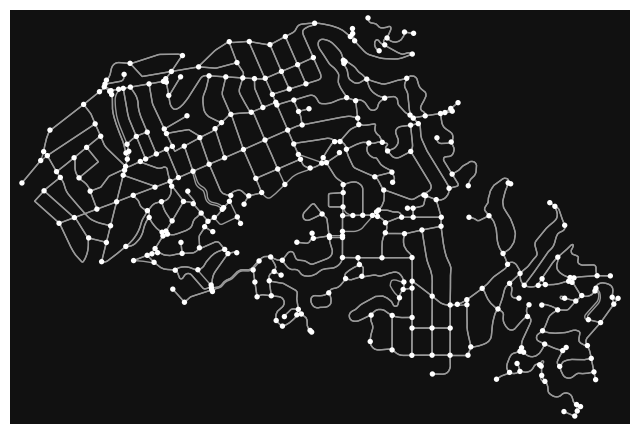

In [2]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Nantes, France", network_type="drive")
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

### Preprocessing

In [3]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'demand': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 8}


In [4]:
# G3=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
G3=nx.DiGraph(G)

In [5]:
len(max(list(nx.strongly_connected_components(G3)), key=len))/G3.number_of_nodes()

0.9914772727272727

In [6]:
# Get strongly connected component
G4 = max(list(nx.strongly_connected_components(G3)), key=len)
G4 = G3.subgraph(G4)

In [7]:
nx.has_path(G4, 53097586, 53097586)

True

### Bla

In [8]:
class Car:
    def __init__(self, departure_node, arrival_node, path):
        self.dep=departure_node
        self.old_loc=departure_node
        self.path=path
        self.loc=departure_node
        self.arr=arrival_node
        self.completed=(departure_node==arrival_node)
    
    def update_loc(self, new_loc):
        self.old_loc=self.loc
        self.loc=new_loc
        self.completed=(self.loc==self.arr)
        return self
    
    def __repr__(self):
        return f'({self.dep}, {self.loc}, {self.arr}, {self.completed})'

In [ ]:
class Car_fleet:
    def __init__(self, graph, size=2*50, replace=False):
        self.graph: nx.DiGraph = graph
        self.rx_helper=rx_helper(self.graph)
        self.all_paths = self.rx_helper.get_all_shortest_paths()

        cnt=0
        while True:
            trajs = self.init_trajs(size, replace)
            if all(nx.has_path(graph, s, t) for s, t in trajs):
                break
            cnt+=1
            print(f"{cnt}th time regenerating trajectories: some nodes were disconnected.", end='\r')
        self.trajs = trajs

        self.fleet = [Car(s, t, self.all_paths[s][t][0]) for s, t in self.trajs]
        self.num_cars = len(trajs)
        self.edges_state = {(car.dep, car.arr) :
            self.check_edges_along_path(car.path) for car in self.fleet
        }
        self.step=0
        self.info=[]

    def init_trajs(self, size, replace):
        nodes_list=list(self.graph.nodes)
        chosen=np.random.choice(self.graph.number_of_nodes(), size, replace)
        sources = [nodes_list[k] for k in chosen[:size//2]]
        targets = [nodes_list[k] for k in chosen[size//2:size]]
        return list(zip(sources, targets))

    def __repr__(self):
        return f'{self.fleet}'

    def get_loc(self):
        return [car.loc for car in self.fleet]
    def get_arr(self):
        return [car.arr for car in self.fleet]
    def get_completed(self):
        return [car.completed for car in self.fleet]
    def all_completed(self):
        return all(self.get_completed())
    
    def get_paths(self):
        return [car.path for car in self.fleet if not car.completed]

    def get_edge_blocked(self):
        return {(u,v):edge_data['weight']>2 for u,v,edge_data in list(self.graph.edges(data=True))}
    
    def handle_interactions(self, node1, node2, demand_delta, new_weight, op):
        if node1!=node2: # Prevent self-loops from interacting (arrival node for example)
            is_multi = 0 in (edge:=self.graph[node1][node2])
            if is_multi:
                # TO NOTE : Only handle first edge in multilinks
                edge=edge[0]
            edge['demand']+=demand_delta
            if op(edge['demand'], edge['capacity']):
                if is_multi:
                    self.graph[node1][node2][0]['weight']=new_weight
                else:
                    self.graph[node1][node2]['weight']=new_weight

    def get_path(self, node1, node2, weight):
        return self.rx_helper.get_shortest_path(node1, node2, weight)
    
    def get_cost(self, path, weight):
        return nx.path_weight(self.graph, path, weight)

    def get_path_and_cost(self, node1, node2, weight):
        path = self.rx_helper.get_shortest_path(node1, node2, weight)
        cost = nx.path_weight(self.graph, path, weight)
        return path, cost
    
    def check_edges_along_path(self, path, dist=3):
        edges = []
        for k, (u, v) in enumerate(itertools.pairwise(path), start=1):
            if u == v:
                edges.append(0)
                continue
            
            if k<=dist: 
                edge_data = self.graph[u][v]
                
                if 0 in edge_data:
                    edges.append(edge_data[0]['weight'])
                else:
                    edges.append(edge_data['weight'])
                
        return edges
    
    def get_paths_to_calculate(self, paths, edges_state:dict, dist=3):
        """
    Returns the paths that have new blocked roads nearby.
    For now, only checks if the state of the road have changed.
        """
        to_calculate=[]
        if dist>len(edges_state):
            dist=len(edges_state)

        for k, path in enumerate(paths):
            s,t = path[0], path[-1]
            edge_state=edges_state[(s,t)]
            if self.check_edges_along_path(path, dist)!=edge_state[:dist] or all(path):
                to_calculate.append((s, t))
                
        return to_calculate
    
    @timeit
    def display(self, ax, edge_alpha=None, edge_list=None):
        node_c = get_dict(list(self.graph.nodes), self.get_loc(), self.get_arr(), 'r', 'g', 'grey')
        node_size = {node:Count(self.get_loc())[node]*15 for node in list(self.graph.nodes)}
        if edge_list:
            edge_c = {(u,v):'y' if edge_data['weight']>2 else 'grey' for u,v,edge_data in list(self.graph.edges(data=True))}
            for edge in self.info:
                edge_c[edge]='r'
            
        ox.plot.plot_graph(
                nx.MultiDiGraph(self.graph),
                ax=ax,          # Use the animation's axis
                show=False,     # Don't open a new window now
                close=False,    # Don't close the plot
                node_color=list(node_c.values()),
                node_size=list(node_size.values()),
                edge_alpha=edge_alpha if edge_alpha else None,
                edge_color=list(edge_c.values()) if edge_c else None
            )
        
    @timeit
    def calculate_paths(self, dist):
        unique = set(tuple(item) for item in self.get_paths())
        deduplicated_paths = [list(item) for item in unique]
        to_calculate=self.get_paths_to_calculate(deduplicated_paths, self.edges_state, dist)

        for s,t in to_calculate:
            path = self.get_path(s, t, weight='weight')
            self.edges_state[(s,t)] = self.check_edges_along_path(path)
            self.all_paths[s][t] = [path]

    @timeit
    def update_fleet(self, interactions):
        for car in self.fleet:
            if interactions and self.step>0:
                self.handle_interactions(car.old_loc, car.loc, -1, 1, op=operator.lt) # Update old edges
        
            if not car.completed:
                path = self.all_paths[car.loc][car.arr][0]
                cost = nx.path_weight(self.graph, path, 'weight')

                car.update_loc(path[1])
                if interactions:
                    self.handle_interactions(car.loc, path[1], 1, 10000, op=operator.ge) # Update new edges

                if cost > 10000:
                    self.info.append((path[0], path[1]))
            else:
                path, cost = [car.loc, car.loc], 0

    def run(self, interactions=True):
        self.info=[]
        if not self.all_completed():
            self.calculate_paths(dist=3)
            self.update_fleet(interactions)
            self.step+=1


### Dynamique induite et update

91it [00:10, 26.41it/s]                        

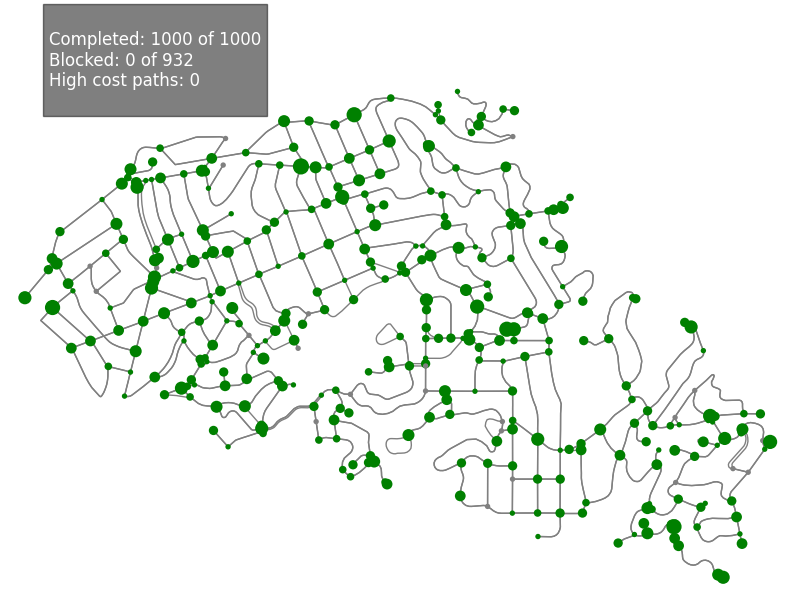

91it [00:15,  5.97it/s]


In [ ]:
demand=Car_fleet(G4.copy(), size=2*1000, replace=True)
frames=90
logging.info(f'__________________________________________________________________')

def update(frame):
    pbar.update(1)
    if demand.all_completed():
        return ax,
    
    ax.clear()
    if frame > 0:
        demand.run(interactions=True)
    demand.display(ax=ax, edge_list=True)
    string=f'''
Completed: {sum(demand.get_completed())} of {demand.num_cars}
Blocked: {sum(demand.get_edge_blocked().values())} of {demand.graph.number_of_edges()}
High cost paths: {len(demand.info)}
'''
    ax.text(0.05, 0.95, string,
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5))
    return ax,

with tqdm(total=frames) as pbar:
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, update, frames=frames, interval=150, repeat=False)
    ani.save("ani.gif", writer='pillow')
    plt.show()